# Unidade V — Classificação e Regressão

## Bagging e florestas aleatórias

**Carga estimada:** 2 horas  
**Pré-requisitos:** treino/teste, árvores de decisão e métricas.

> **Pergunta norteadora:** como combinar modelos treinados sobre versões diferentes dos dados para obter previsões mais estáveis?

Bagging é uma família de **ensemble**: treinamos vários modelos e agregamos suas previsões. Este notebook o separa por importância didática e o conecta às florestas aleatórias.

## Objetivos de aprendizagem

- explicar amostragem *bootstrap* e objetos *out-of-bag*;
- descrever o fluxo do *bootstrap aggregation*;
- relacionar bagging à redução de variância;
- comparar árvore, bagging e floresta aleatória;
- explicar como a seleção aleatória de atributos aumenta a diversidade;
- interpretar o escore OOB sem confundi-lo com o teste final.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="colorblind")

## 1. Bagging dentro dos ensembles

Um **ensemble** combina modelos-base. Bagging cria diversidade com amostras *bootstrap* e combina votos ou médias com pesos iguais. A floresta aleatória adiciona subconjuntos aleatórios de atributos; boosting cria modelos sequenciais que dão atenção aos erros anteriores.

Portanto, **bagging é um tipo de ensemble**. A separação em um notebook próprio é pedagógica; o notebook 05.06 estudará votação e boosting.

## 2. Bootstrap: novas amostras a partir do treino

Dado um treino com $n$ objetos, uma amostra *bootstrap* sorteia $n$ vezes **com reposição**. Um objeto pode aparecer várias vezes; outro pode não aparecer. Os não sorteados são **out-of-bag (OOB)** naquela amostra. O teste nunca participa desses sorteios.

In [2]:
objetos = np.array(list("ABCDEFGH"))
rng = np.random.default_rng(RANDOM_STATE)
sorteados = rng.choice(objetos, size=len(objetos), replace=True)
contagens = pd.Series(sorteados).value_counts().reindex(objetos, fill_value=0)
tabela_bootstrap = pd.DataFrame({
    "objeto": objetos,
    "quantidade_na_amostra": contagens.to_numpy(),
    "situação": np.where(contagens.to_numpy() == 0, "out-of-bag", "in-bag"),
})
print("Sequência sorteada:", " ".join(sorteados))
display(tabela_bootstrap)

Sequência sorteada: A G F D D G A F


,objeto,quantidade_na_amostra,situação
0,A,2,in-bag
1,B,0,out-of-bag
2,C,0,out-of-bag
3,D,2,in-bag
4,E,0,out-of-bag
5,F,2,in-bag
6,G,2,in-bag
7,H,0,out-of-bag


## 3. Bagging passo a passo

Para $b=1,\ldots,B$: sorteie um *bootstrap* $D_b$, ajuste $M_b$ e guarde sua previsão. Na classificação:

$$\hat y(x)=\operatorname{moda}\{M_1(x),\ldots,M_B(x)\}.$$

Na regressão:

$$\hat y(x)=\frac{1}{B}\sum_{b=1}^{B}M_b(x).$$

Árvores profundas são instáveis: pequenas mudanças nos dados podem alterar muitas divisões. Agregar modelos pode reduzir essa variância quando seus erros não são perfeitamente correlacionados. Isso não corrige automaticamente viés, dados ruins ou vazamento.

## 4. Estudo de caso: uma fronteira não linear

Usaremos duas regiões curvas com sobreposição. A partição treino/teste é feita uma vez; os *bootstraps* pertencem apenas ao ajuste.

In [3]:
X, y = make_moons(n_samples=700, noise=0.30, random_state=RANDOM_STATE)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
modelos = {
    "Árvore única": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(), n_estimators=120,
        max_samples=0.80, bootstrap=True, oob_score=True,
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    "Floresta aleatória": RandomForestClassifier(
        n_estimators=200, max_features="sqrt", oob_score=True,
        n_jobs=-1, random_state=RANDOM_STATE
    ),
}
linhas = []
for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_teste)
    linhas.append({"modelo": nome, "acurácia_teste": accuracy_score(y_teste, pred),
                   "F1_teste": f1_score(y_teste, pred)})
resultados = pd.DataFrame(linhas)
display(resultados.round(3))

,modelo,acurácia_teste,F1_teste
0,Árvore única,0.829,0.832
1,Bagging,0.890,0.893
2,Floresta aleatória,0.871,0.872


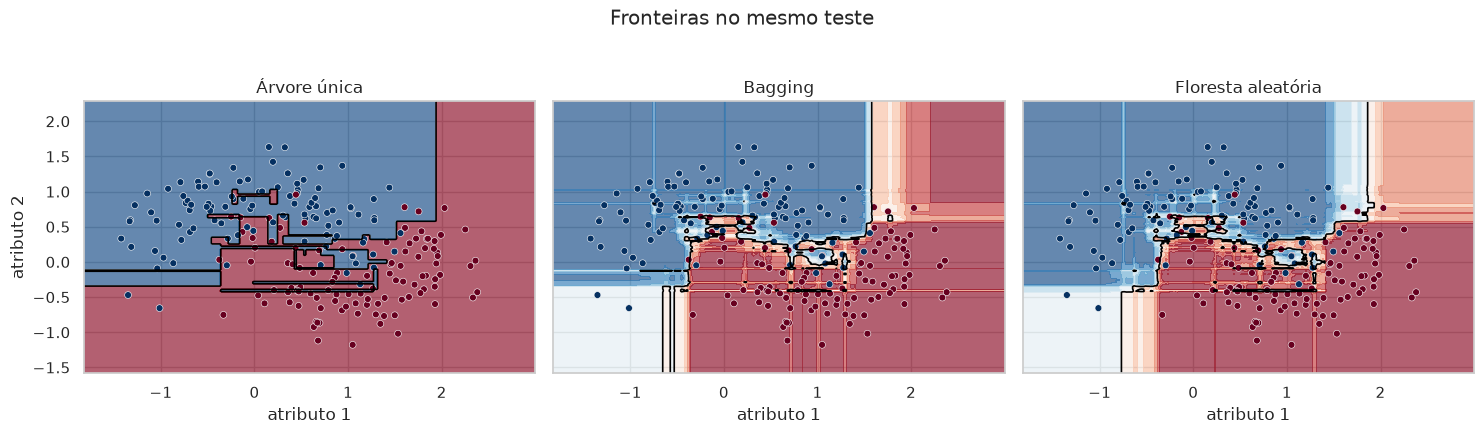

In [4]:
x1 = np.linspace(X[:, 0].min() - .4, X[:, 0].max() + .4, 240)
x2 = np.linspace(X[:, 1].min() - .4, X[:, 1].max() + .4, 240)
xx, yy = np.meshgrid(x1, x2)
grade = np.c_[xx.ravel(), yy.ravel()]
fig, eixos = plt.subplots(1, 3, figsize=(15, 4.2), sharex=True, sharey=True)
for ax, (nome, modelo) in zip(eixos, modelos.items()):
    prob = modelo.predict_proba(grade)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, prob, levels=np.linspace(0, 1, 11), cmap="RdBu_r", alpha=.65)
    ax.contour(xx, yy, prob, levels=[.5], colors="black", linewidths=1.2)
    ax.scatter(X_teste[:, 0], X_teste[:, 1], c=y_teste, cmap="RdBu_r",
               edgecolor="white", linewidth=.4, s=24)
    ax.set_title(nome); ax.set_xlabel("atributo 1")
eixos[0].set_ylabel("atributo 2")
fig.suptitle("Fronteiras no mesmo teste", y=1.03)
plt.tight_layout(); plt.show()

## 5. Estabilidade diante de mudanças no treino

Reamostraremos o treino várias vezes e avaliaremos sempre no **mesmo teste**. Bagging deve variar menos que uma árvore profunda isolada. Isso não garante vitória em toda execução: com poucos dados, modelos muito correlacionados ou erro sistemático, o ganho pode ser pequeno.

,mean,std,min,max
modelo,,,,
Bagging,0.872,0.014,0.852,0.905
Árvore única,0.846,0.021,0.805,0.881


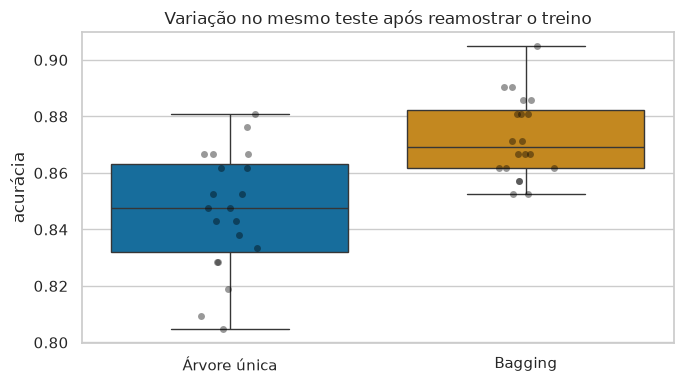

In [5]:
avaliacoes = []
for semente in range(20):
    rng = np.random.default_rng(semente)
    idx = rng.choice(len(X_treino), size=len(X_treino), replace=True)
    X_b, y_b = X_treino[idx], y_treino[idx]
    candidatos = {
        "Árvore única": DecisionTreeClassifier(random_state=semente),
        "Bagging": BaggingClassifier(
            estimator=DecisionTreeClassifier(), n_estimators=50,
            max_samples=.8, n_jobs=-1, random_state=semente
        ),
    }
    for nome, modelo in candidatos.items():
        modelo.fit(X_b, y_b)
        avaliacoes.append({"modelo": nome,
            "acurácia": accuracy_score(y_teste, modelo.predict(X_teste))})
avaliacoes = pd.DataFrame(avaliacoes)
display(avaliacoes.groupby("modelo")["acurácia"].agg(["mean", "std", "min", "max"]).round(3))
plt.figure(figsize=(7, 4))
sns.boxplot(data=avaliacoes, x="modelo", y="acurácia", hue="modelo", legend=False)
sns.stripplot(data=avaliacoes, x="modelo", y="acurácia", color="black", alpha=.4)
plt.title("Variação no mesmo teste após reamostrar o treino")
plt.xlabel(""); plt.tight_layout(); plt.show()

## 6. Da bagging à floresta aleatória

Se todas as árvores enxergarem todos os atributos, um preditor dominante pode aparecer cedo em quase todas elas. A floresta aleatória considera somente um subconjunto aleatório de atributos candidatos em cada nó. Isso pode diminuir a correlação entre árvores. O parâmetro **max_features** controla essa disponibilidade; diversidade ajuda, mas árvores fracas demais também prejudicam.

,modelo,acurácia_teste,F1_teste,correlação_média_entre_árvores
0,Árvore única,0.829,0.832,NaN
1,Bagging,0.890,0.893,0.708
2,Floresta aleatória,0.871,0.872,0.701


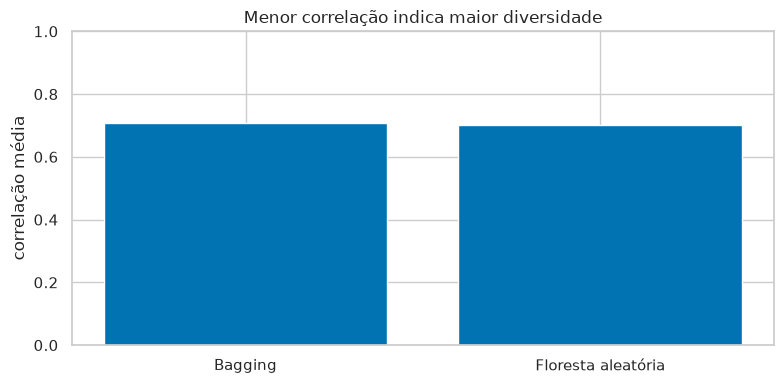

In [6]:
def correlacao_media(modelo, X_avaliacao):
    probabilidades = np.vstack([
        estimador.predict_proba(X_avaliacao)[:, 1]
        for estimador in modelo.estimators_
    ])
    matriz = np.corrcoef(probabilidades)
    return np.nanmean(matriz[np.triu_indices_from(matriz, k=1)])

comparacao = resultados.copy()
comparacao["correlação_média_entre_árvores"] = [
    np.nan, correlacao_media(modelos["Bagging"], X_teste),
    correlacao_media(modelos["Floresta aleatória"], X_teste)
]
display(comparacao.round(3))
dados = comparacao.dropna()
plt.figure(figsize=(8, 4))
plt.bar(dados["modelo"], dados["correlação_média_entre_árvores"])
plt.ylim(0, 1); plt.ylabel("correlação média")
plt.title("Menor correlação indica maior diversidade")
plt.tight_layout(); plt.show()

## 7. Avaliação out-of-bag

Para cada objeto do treino, agregam-se apenas as árvores em cujos *bootstraps* ele não apareceu. Isso gera uma estimativa OOB sem separar outra parte do treino. OOB é diagnóstico, não substituto automático do teste; com poucas árvores, alguns objetos recebem poucas avaliações.

In [7]:
bagging = modelos["Bagging"]
floresta = modelos["Floresta aleatória"]
comparacao_oob = pd.DataFrame({
    "modelo": ["Bagging", "Floresta aleatória"],
    "acurácia_OOB": [bagging.oob_score_, floresta.oob_score_],
    "acurácia_teste": [
        accuracy_score(y_teste, bagging.predict(X_teste)),
        accuracy_score(y_teste, floresta.predict(X_teste)),
    ],
})
comparacao_oob["diferença_absoluta"] = (
    comparacao_oob["acurácia_OOB"] - comparacao_oob["acurácia_teste"]
).abs()
display(comparacao_oob.round(3))

,modelo,acurácia_OOB,acurácia_teste,diferença_absoluta
0,Bagging,0.869,0.890,0.021
1,Floresta aleatória,0.857,0.871,0.014


## Atividades

### U05-NB05-V01 — Bootstrap e OOB

Para os objetos $\{A,B,C,D\}$, a amostra foi **[B, B, D, A]**. Conte as ocorrências, identifique o objeto OOB e explique por que a amostra ainda tem tamanho quatro.

### U05-NB05-E01 — Voto e diversidade

Cinco árvores preveem $[1,1,0,1,0]$. Determine o voto majoritário e explique o que se perde se todas as árvores sempre cometerem os mesmos erros.

### U05-NB05-E02 — Bagging versus floresta aleatória

Explique o que têm em comum, qual aleatoriedade adicional existe na floresta e o possível efeito de reduzir demais **max_features**.

### U05-NB05-E03 — Escolha responsável

Uma árvore obtém acurácia 0,84. Um bagging obtém 0,86, OOB 0,85 e demora 40 vezes mais para treinar. Decida considerando desempenho, estabilidade, custo, interpretabilidade e finalidade.

## Síntese

- Bagging treina modelos em amostras *bootstrap* e agrega previsões.
- Voto ou média podem reduzir variância quando os erros diferem.
- A floresta aleatória acrescenta seleção aleatória de atributos.
- OOB avalia cada objeto por árvores que não o usaram no ajuste.
- Ganho preditivo não elimina custos, limitações ou necessidade de teste independente.

## Referências

- HAN, J.; PEI, J.; TONG, H. *Data Mining: Concepts and Techniques*. 4. ed. Morgan Kaufmann, 2023. Seções 6.7.1, 6.7.2 e 6.7.4.
- SCIKIT-LEARN DEVELOPERS. Documentação de BaggingClassifier e RandomForestClassifier.

Dados e figuras autorais, gerados localmente.